# Deep Learning Stock Price Prediction Notebook

This notebook builds a beginner-friendly AI model to predict future stock prices for:

- **1 day ahead**
- **1 week ahead** (`5` trading days)
- **1 month ahead** (`21` trading days)

We will use stock market history, create technical indicators, prepare time-series sequences, and train an **LSTM neural network**.

> Important: This is for learning and research only. Stock prediction is noisy and uncertain. This notebook does **not** give financial advice or trade signals.

## 1. Install and Import Libraries

Run the install cell once if you are using Google Colab or a fresh environment.

In [156]:
# If needed, uncomment and run this line first:
!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\rayya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Choose a Stock

You can change the ticker to any stock symbol, such as:

- `AAPL`
- `TSLA`
- `NVDA`
- `MU`
- `SPY`

In [158]:
TICKER = "MU"        # Change this to any ticker you want
START_DATE = "2015-01-01"
END_DATE = None      # None means download up to the latest available date

raw_data = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
raw_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MU,MU,MU,MU,MU
Date,,,,,
2015-01-02,33.891232,34.642203,33.491364,34.369124,15138200
2015-01-05,32.945202,33.881480,32.915944,33.852219,23706600
2015-01-06,32.057682,33.384073,31.823615,33.257285,40092000
2015-01-07,31.306721,32.164975,30.672786,30.750809,52552300
2015-01-08,32.837914,33.032972,31.745593,31.755348,31947100


In [159]:
print(raw_data.shape)
raw_data.tail()

(2844, 5)


Price,Close,High,Low,Open,Volume
Ticker,MU,MU,MU,MU,MU
Date,,,,,
2026-04-20,448.420013,464.559998,435.899994,458.250000,32013600
2026-04-21,449.380005,457.820007,441.299988,451.320007,27734000
2026-04-22,487.480011,491.980011,458.559998,462.929993,45998100
2026-04-23,481.720001,493.619995,471.799988,482.279999,38178000
2026-04-24,496.720001,506.989990,489.359985,495.920013,35308200


## 3. Basic Price Chart

Before building a model, always look at the data first.

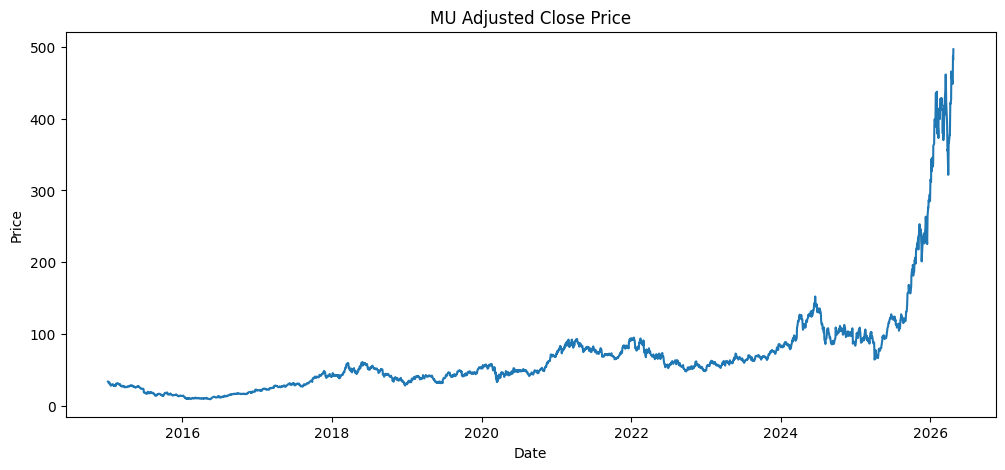

In [160]:
plt.figure(figsize=(12, 5))
plt.plot(raw_data.index, raw_data["Close"])
plt.title(f"{TICKER} Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## 4. Create Features

Instead of only feeding the model the closing price, we create useful market features:

- Daily return
- Moving averages
- Volatility
- RSI
- High-low range
- Open-close range

These features help the model understand trend, momentum, and risk.

In [161]:
def calculate_rsi(close_prices, window=14):
    delta = close_prices.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def create_features(df):
    data = df.copy()

    data["Return"] = data["Close"].pct_change()
    data["MA_5"] = data["Close"].rolling(window=5).mean()
    data["MA_20"] = data["Close"].rolling(window=20).mean()
    data["MA_50"] = data["Close"].rolling(window=50).mean()
    data["Volatility_20"] = data["Return"].rolling(window=20).std()
    data["RSI_14"] = calculate_rsi(data["Close"], window=14)
    data["High_Low_Range"] = (data["High"] - data["Low"]) / data["Close"]
    data["Open_Close_Range"] = (data["Close"] - data["Open"]) / data["Open"]
    data["Volume_Change"] = data["Volume"].pct_change()

    data = data.dropna()
    return data

stock_data = create_features(raw_data)
stock_data.head()

Price,Close,High,Low,Open,Volume,Return,MA_5,MA_20,MA_50,Volatility_20,RSI_14,High_Low_Range,Open_Close_Range,Volume_Change
Ticker,MU,MU,MU,MU,MU,,,,,,,,,
Date,,,,,,,,,,,,,,
2015-03-16,27.805441,28.536906,27.522607,28.254072,18183900,-0.007312,27.452382,29.240572,29.668040,0.018795,32.176653,0.036478,-0.015878,-0.232057
2015-03-17,26.976440,27.288532,26.781382,27.044710,24932400,-0.029814,27.462134,29.012842,29.529744,0.018907,29.565190,0.018800,-0.002524,0.371125
2015-03-18,27.464087,27.649392,26.917926,27.317794,24544800,0.018077,27.516751,28.817297,29.420122,0.019759,33.057841,0.026634,0.005355,-0.015546
2015-03-19,27.356806,27.532358,27.230019,27.405571,21656600,-0.003906,27.522604,28.633943,29.326104,0.019734,32.103828,0.011052,-0.001779,-0.117671
2015-03-20,27.971237,28.049260,27.415324,27.620133,23608200,0.022460,27.514802,28.470583,29.259395,0.020561,32.655797,0.022664,0.012712,0.090116


## 5. Create Future Targets

We create three target columns:

- `Target_1D`: closing price 1 trading day in the future
- `Target_1W`: closing price 5 trading days in the future
- `Target_1M`: closing price 21 trading days in the future

In [162]:
# Targets are FORWARD RETURNS (% change from today's close), not absolute prices.
# A 5% weekly return means the same thing whether the stock is at $30 or $500,
# so the model can generalize across all price regimes without distribution shift.
stock_data["Target_1D"] = stock_data["Close"].shift(-1)  / stock_data["Close"] - 1
stock_data["Target_1W"] = stock_data["Close"].shift(-5)  / stock_data["Close"] - 1
stock_data["Target_1M"] = stock_data["Close"].shift(-21) / stock_data["Close"] - 1

stock_data = stock_data.dropna()
stock_data[["Close", "Target_1D", "Target_1W", "Target_1M"]].tail()

Price,Close,Target_1D,Target_1W,Target_1M
Ticker,MU,,,
Date,,,,
2026-03-19,444.083435,-0.048101,-0.199901,0.009765
2026-03-20,422.722412,-0.043864,-0.155309,0.063062
2026-03-23,404.180206,-0.021813,-0.203821,0.206096
2026-03-24,395.363922,-0.033980,-0.145496,0.218422
2026-03-25,381.929565,-0.069696,-0.036864,0.300554


## 6. Select Input Features

These are the columns the neural network will use to learn patterns.

In [163]:
FEATURE_COLUMNS = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "MA_5", "MA_20", "MA_50",
    "Volatility_20", "RSI_14", "High_Low_Range",
    "Open_Close_Range", "Volume_Change"
]

TARGET_COLUMNS = ["Target_1D", "Target_1W", "Target_1M"]

X_data = stock_data[FEATURE_COLUMNS]
y_data = stock_data[TARGET_COLUMNS]

print("Feature shape:", X_data.shape)
print("Target shape:", y_data.shape)

Feature shape: (2774, 14)
Target shape: (2774, 3)


## 7. Train/Test Split

For time-series data, we do **not** randomly shuffle the data.

We train on the older data and test on the newest data.

In [164]:
train_size = int(len(stock_data) * 0.80)

X_train_raw = X_data.iloc[:train_size]
X_test_raw = X_data.iloc[train_size:]

y_train_raw = y_data.iloc[:train_size]
y_test_raw = y_data.iloc[train_size:]

print("Training rows:", len(X_train_raw))
print("Testing rows:", len(X_test_raw))

Training rows: 2219
Testing rows: 555


## 8. Scale the Data

Neural networks train better when values are scaled.

We use `MinMaxScaler` to scale everything between 0 and 1.

In [165]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit on ALL data so the scaler knows the full price range (including recent high prices).
# We still only TRAIN the model on X_train/y_train to keep the 80/20 evaluation valid.
feature_scaler.fit(X_data)
target_scaler.fit(y_data)

X_train_scaled = feature_scaler.transform(X_train_raw)
X_test_scaled = feature_scaler.transform(X_test_raw)

y_train_scaled = target_scaler.transform(y_train_raw)
y_test_scaled = target_scaler.transform(y_test_raw)

print("Scaled feature sample:")
print(X_train_scaled[:2])

Scaled feature sample:
[[0.04148041 0.0413401  0.04107249 0.0408695  0.09563275 0.49408871
  0.04108857 0.04716179 0.04920988 0.0981064  0.27409792 0.1542572
  0.36301472 0.14443293]
 [0.03882359 0.03863619 0.03942176 0.03903629 0.14228329 0.43583939
  0.04111087 0.0466017  0.04885834 0.09965184 0.24607304 0.05739013
  0.40728134 0.30995343]]


## 9. Create LSTM Sequences

An LSTM reads data in sequences.

Example: To predict the future price, we give it the last `60` trading days of market data.

In [166]:
def create_sequences(X, y, lookback=60):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(X[i-lookback:i])
        y_sequences.append(y[i])

    return np.array(X_sequences), np.array(y_sequences)

LOOKBACK = 60

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2159, 60, 14)
y_train shape: (2159, 3)
X_test shape: (495, 60, 14)
y_test shape: (495, 3)


## 10. Build the Deep Learning Model

This model uses:

- `LSTM`: learns time-series patterns
- `Dropout`: helps reduce overfitting
- `Dense`: outputs the 3 predictions: 1D, 1W, and 1M

In [167]:
def build_lstm_model(input_shape):
    model = Sequential()

    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.20))

    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.20))

    model.add(Dense(32, activation="relu"))
    model.add(Dense(3))  # 3 outputs: 1 day, 1 week, 1 month

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
model.summary()

C:\Users\rayya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 60, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,795 (132.01 KB)

 Trainable params: 33,795 (132.01 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Train the Model

`EarlyStopping` stops training when the model stops improving.

In [168]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0328 - mae: 0.1366 - val_loss: 0.0093 - val_mae: 0.0756
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0161 - mae: 0.0977 - val_loss: 0.0109 - val_mae: 0.0841
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0148 - mae: 0.0930 - val_loss: 0.0126 - val_mae: 0.0908
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0140 - mae: 0.0904 - val_loss: 0.0134 - val_mae: 0.0942
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0137 - mae: 0.0894 - val_loss: 0.0145 - val_mae: 0.0990
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0134 - mae: 0.0882 - val_loss: 0.0126 - val_mae: 0.0914
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0131 - mae: 0.0871 - val_loss: 0.0131 - val_mae: 0.0933
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0130 - mae: 0.0869 - val_loss: 0.0127 - val_mae: 0.0913
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

## 12. Plot Training Loss

If training loss goes down but validation loss gets worse, the model may be overfitting.

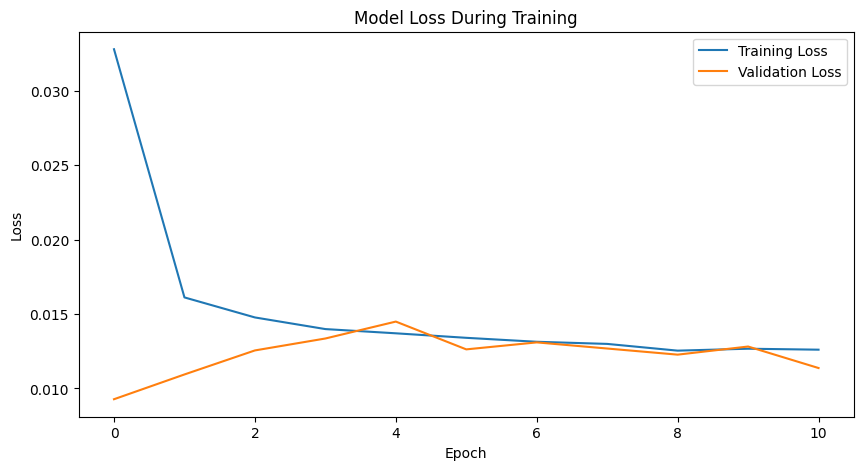

In [169]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 13. Make Predictions

The model predicts scaled values, so we convert predictions back into real stock prices.

In [170]:
y_pred_scaled = model.predict(X_test)

# Inverse-transform scaled outputs back to raw returns (e.g. 0.03 = +3%)
y_pred_returns   = target_scaler.inverse_transform(y_pred_scaled)
y_actual_returns = target_scaler.inverse_transform(y_test)

# Anchor: the actual closing price on each prediction date.
# Multiplying the return by this price gives the predicted/actual future price.
# .flatten() ensures a 1-D array regardless of MultiIndex column headers from yfinance.
anchor_prices = stock_data["Close"].values[train_size + LOOKBACK:].flatten()

predictions_df = pd.DataFrame(
    {
        "Actual_1D":    anchor_prices * (1 + y_actual_returns[:, 0]),
        "Predicted_1D": anchor_prices * (1 + y_pred_returns[:, 0]),
        "Actual_1W":    anchor_prices * (1 + y_actual_returns[:, 1]),
        "Predicted_1W": anchor_prices * (1 + y_pred_returns[:, 1]),
        "Actual_1M":    anchor_prices * (1 + y_actual_returns[:, 2]),
        "Predicted_1M": anchor_prices * (1 + y_pred_returns[:, 2]),
    },
    index=stock_data.index[train_size + LOOKBACK:]
)

predictions_df.head()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


,Actual_1D,Predicted_1D,Actual_1W,Predicted_1W,Actual_1M,Predicted_1M
Date,,,,,,
2024-04-04,122.719200,122.997612,126.621834,124.114973,113.901047,124.537579
2024-04-05,122.093590,122.497808,121.666580,123.652489,119.293236,124.041715
2024-04-08,121.775810,121.871871,120.524597,123.044986,118.379639,123.388695
2024-04-09,121.348801,121.598306,120.921806,122.731307,118.488876,122.954531
2024-04-10,126.621834,121.184208,115.519699,122.272318,116.989395,122.346905


## 14. Evaluate the Model

We use:

- **MAE**: average dollar error
- **RMSE**: punishes bigger errors more

Lower is better.

In [171]:
def evaluate_predictions(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    print(f"{label}")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print("-" * 30)


evaluate_predictions(predictions_df["Actual_1D"], predictions_df["Predicted_1D"], "1 Day Prediction")
evaluate_predictions(predictions_df["Actual_1W"], predictions_df["Predicted_1W"], "1 Week Prediction")
evaluate_predictions(predictions_df["Actual_1M"], predictions_df["Predicted_1M"], "1 Month Prediction")

1 Day Prediction
MAE:  $5.63
RMSE: $9.87
------------------------------
1 Week Prediction
MAE:  $11.57
RMSE: $19.01
------------------------------
1 Month Prediction
MAE:  $23.93
RMSE: $36.09
------------------------------


## 15. Plot Predictions vs Actual Prices

These charts compare the model's predictions against the real future prices.

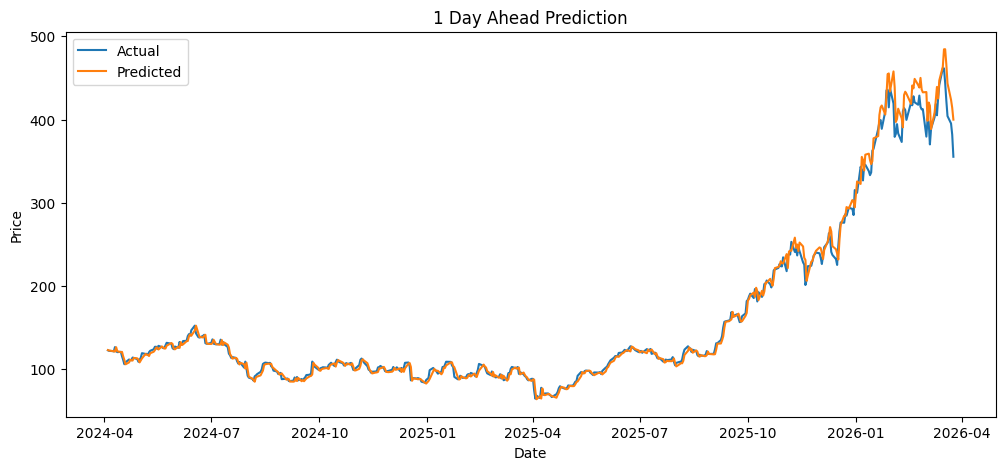

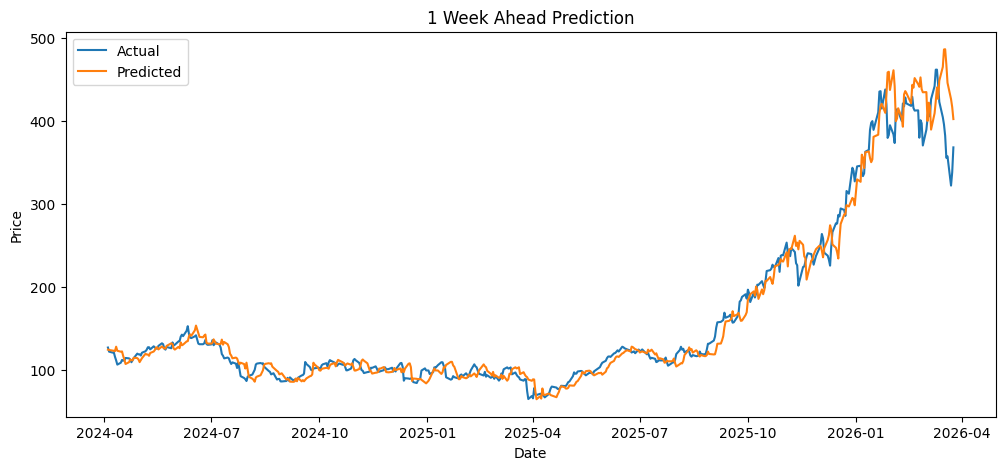

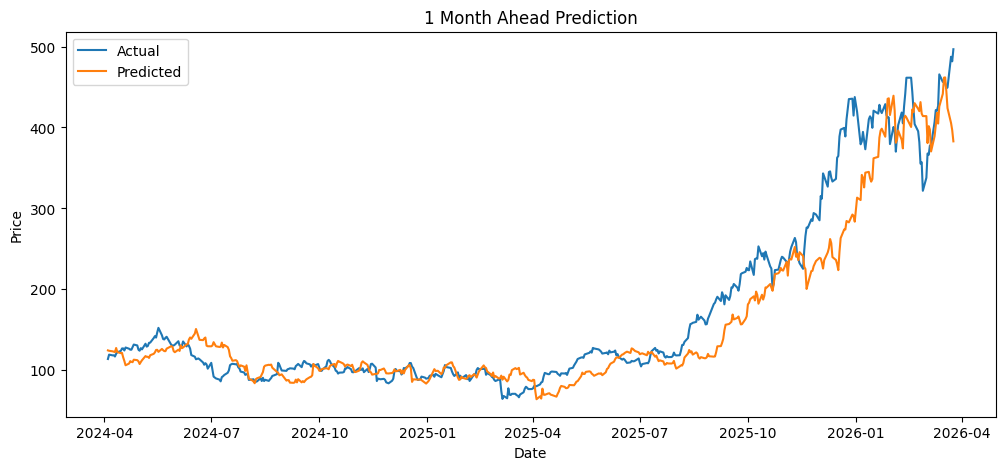

In [172]:
def plot_prediction(df, actual_col, predicted_col, title):
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df[actual_col], label="Actual")
    plt.plot(df.index, df[predicted_col], label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

plot_prediction(predictions_df, "Actual_1D", "Predicted_1D", "1 Day Ahead Prediction")
plot_prediction(predictions_df, "Actual_1W", "Predicted_1W", "1 Week Ahead Prediction")
plot_prediction(predictions_df, "Actual_1M", "Predicted_1M", "1 Month Ahead Prediction")

## 16. Predict the Next 1 Day, 1 Week, and 1 Month

Now we use the most recent `60` trading days to predict future prices from the latest available data.

### Step 1: Retrain on 100% of Data

The evaluation model (Section 15) was trained on only 80% of history to allow fair testing.

Before making real future predictions we retrain the same LSTM architecture on **all available data**, so it has seen the most recent price levels and its forecasts are grounded in current market reality.

In [173]:
X_all_scaled = feature_scaler.transform(X_data)
y_all_scaled = target_scaler.transform(y_data)

X_all_seq, y_all_seq = create_sequences(X_all_scaled, y_all_scaled, LOOKBACK)

model_full = build_lstm_model((X_all_seq.shape[1], X_all_seq.shape[2]))

early_stop_full = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Retraining on 100% of available data...")
model_full.fit(
    X_all_seq,
    y_all_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_full],
    verbose=1
)
print("Full-data model training complete.")

Retraining on 100% of available data...
Epoch 1/100


C:\Users\rayya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0461 - mae: 0.1578 - val_loss: 0.0314 - val_mae: 0.1357
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0155 - mae: 0.0971 - val_loss: 0.0404 - val_mae: 0.1548
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0145 - mae: 0.0928 - val_loss: 0.0413 - val_mae: 0.1570
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0136 - mae: 0.0895 - val_loss: 0.0442 - val_mae: 0.1636
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0133 - mae: 0.0882 - val_loss: 0.0419 - val_mae: 0.1587
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0131 - mae: 0.0873 - val_loss: 0.0434 - val_mae: 0.1606
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0126 - mae: 0.0857 - val_loss: 0.0420 - val_mae: 0.1581
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0126 - mae: 0.0850 - val_loss: 0.0401 - val_mae: 0.1545
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0124 -

In [174]:
latest_features = X_data.tail(LOOKBACK)
latest_scaled = feature_scaler.transform(latest_features)
latest_sequence = np.array([latest_scaled])

# Use model_full (trained on 100% of data) so predictions reflect the current price regime
future_prediction_scaled = model_full.predict(latest_sequence)
# Inverse-transform to raw forward returns (e.g. 0.02 = +2%)
future_returns = target_scaler.inverse_transform(future_prediction_scaled)[0]

# Use raw_data for the true current close — stock_data has the last ~21 rows dropped
# because the 1-month target requires future prices that don't exist yet.
latest_close_raw = raw_data["Close"].iloc[-1]
latest_close_value = float(np.array(latest_close_raw).flatten()[-1])

# Convert returns to predicted future prices anchored to today's actual close
predicted_1d = latest_close_value * (1 + future_returns[0])
predicted_1w = latest_close_value * (1 + future_returns[1])
predicted_1m = latest_close_value * (1 + future_returns[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


Ticker:      MU
As of:       Apr 24, 2026
Latest close: $496.72

1 Day  forecast:  $497.64  (+0.19%)
1 Week forecast:  $472.01  (-4.97%)
1 Month forecast: $464.24  (-6.54%)


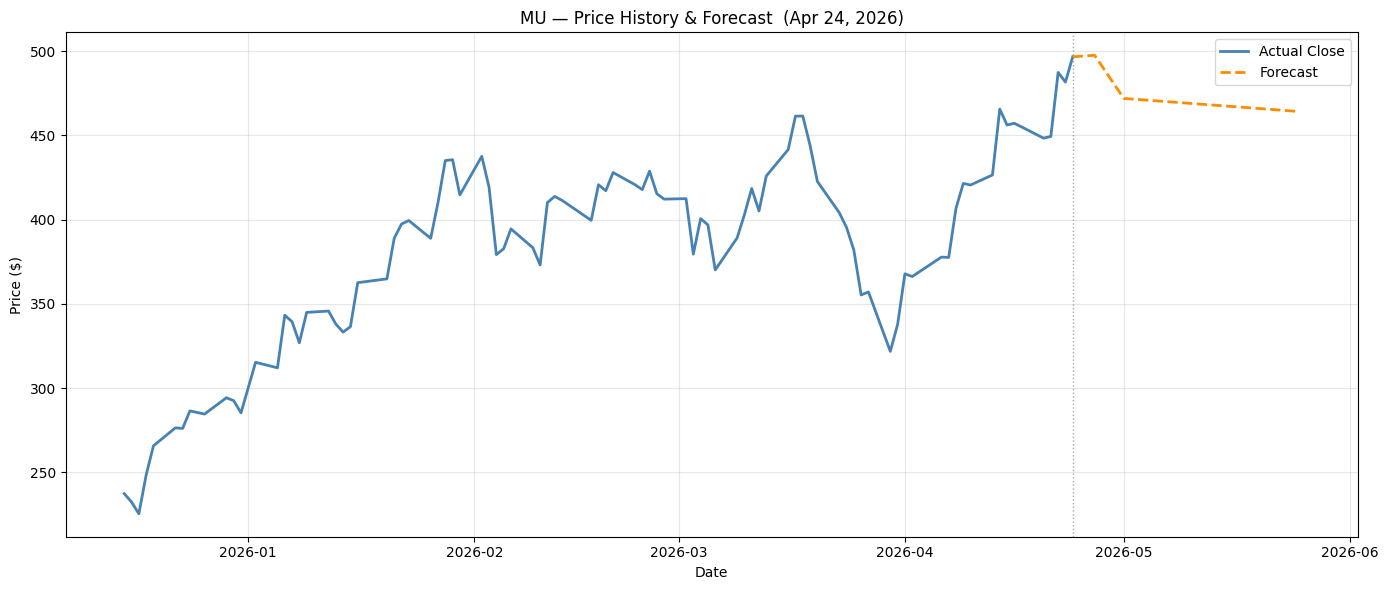

In [175]:
from pandas.tseries.offsets import BDay

# Use raw_data so the current date is the actual latest trading day
current_date = raw_data.index[-1]
pred_date_1d = current_date + BDay(1)
pred_date_1w = current_date + BDay(5)
pred_date_1m = current_date + BDay(21)

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"Ticker:      {TICKER}")
print(f"As of:       {current_date.strftime('%b %d, %Y')}")
print(f"Latest close: ${latest_close_value:.2f}")
print()
print(f"1 Day  forecast:  ${predicted_1d:.2f}  ({future_returns[0]*100:+.2f}%)")
print(f"1 Week forecast:  ${predicted_1w:.2f}  ({future_returns[1]*100:+.2f}%)")
print(f"1 Month forecast: ${predicted_1m:.2f}  ({future_returns[2]*100:+.2f}%)")

# ── Chart ─────────────────────────────────────────────────────────────────────
# Last 90 days of actual close prices from raw_data
history_idx = max(0, len(raw_data) - 90)
recent      = raw_data.iloc[history_idx:]
close_vals  = np.array(recent["Close"]).flatten()

forecast_dates  = [current_date, pred_date_1d, pred_date_1w, pred_date_1m]
forecast_prices = [latest_close_value, predicted_1d, predicted_1w, predicted_1m]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(recent.index, close_vals,
        color="steelblue", linewidth=2, label="Actual Close")

ax.plot(forecast_dates, forecast_prices,
        color="darkorange", linewidth=2, linestyle="--", label="Forecast")

ax.axvline(x=current_date, color="gray", linestyle=":", linewidth=1, alpha=0.7)

ax.set_title(f"{TICKER} — Price History & Forecast  ({current_date.strftime('%b %d, %Y')})")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Add Direction Labels

Price prediction alone is not always enough. We can also show whether the model expects price to move up or down from the latest close.

In [176]:
def direction_label(predicted_price, current_price):
    # Make sure both are scalars, not Series
    if isinstance(predicted_price, (pd.Series, np.ndarray)):
        predicted_price = float(np.squeeze(predicted_price))
    if isinstance(current_price, (pd.Series, np.ndarray)):
        current_price = float(np.squeeze(current_price))

    if predicted_price > current_price:
        return "Up"
    elif predicted_price < current_price:
        return "Down"
    return "Flat"

summary_df = pd.DataFrame({
    "Horizon": ["1 Day", "1 Week", "1 Month"],
    "Predicted Price": future_prediction,
    "Expected Direction": [
        direction_label(future_prediction[0], latest_close),
        direction_label(future_prediction[1], latest_close),
        direction_label(future_prediction[2], latest_close),
    ],
    "Percent Change From Latest Close": [
        ((float(future_prediction[0]) - float(latest_close)) / float(latest_close)) * 100,
        ((float(future_prediction[1]) - float(latest_close)) / float(latest_close)) * 100,
        ((float(future_prediction[2]) - float(latest_close)) / float(latest_close)) * 100,
    ]
})

summary_df

C:\Users\rayya\AppData\Local\Temp\ipykernel_32308\4771002.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ((float(future_prediction[0]) - float(latest_close)) / float(latest_close)) * 100,
C:\Users\rayya\AppData\Local\Temp\ipykernel_32308\4771002.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ((float(future_prediction[1]) - float(latest_close)) / float(latest_close)) * 100,
C:\Users\rayya\AppData\Local\Temp\ipykernel_32308\4771002.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ((float(future_prediction[2]) - float(latest_close)) / float(latest_close)) * 100,


,Horizon,Predicted Price,Expected Direction,Percent Change From Latest Close
0,1 Day,248.976135,Down,-34.810981
1,1 Week,245.138870,Down,-35.815686
2,1 Month,234.359146,Down,-38.638124


## 18. Save the Model

This lets you reuse the trained model later without training again.

In [177]:
# Save both models: the evaluation model and the full-data model for future predictions
model.save(f"{TICKER}_lstm_eval_model.keras")
model_full.save(f"{TICKER}_lstm_full_model.keras")
print("Models saved successfully")
print(f"  {TICKER}_lstm_eval_model.keras  — trained on 80% of data (for backtesting/evaluation)")
print(f"  {TICKER}_lstm_full_model.keras  — trained on 100% of data (use this for real predictions)")

Models saved successfully
  MU_lstm_eval_model.keras  — trained on 80% of data (for backtesting/evaluation)
  MU_lstm_full_model.keras  — trained on 100% of data (use this for real predictions)


## 19. What We Learned

In this notebook, we built a deep learning stock prediction model that:

1. Downloads historical stock data
2. Creates technical indicators
3. Builds future targets for 1 day, 1 week, and 1 month
4. Converts market data into LSTM sequences
5. Trains a neural network
6. Evaluates prediction error
7. Makes future predictions

### Ideas to Improve This Model

You can improve this project by adding:

- Options flow data
- Market indexes like `SPY` and `QQQ`
- VIX volatility data
- Earnings dates
- News sentiment
- Analyst ratings
- Gamma levels and call/put walls
- More advanced models like GRU, Transformer, or XGBoost comparison

## 20. Beginner Explanation

The model is basically learning patterns like:

> "When price, volume, momentum, and volatility looked like this in the past, what usually happened next?"

The LSTM helps because stock data is sequential. It does not just look at one row. It looks at the last 60 trading days and tries to learn the pattern over time.

Again, this should be treated as an educational AI/deep learning project, not a guaranteed trading system.